# Load network
Build edges, nodes, and adjacency list from the input file. 

In [2]:
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import random
import os
import matplotlib.pyplot as plt

edges = np.loadtxt("train.csv", delimiter=",", dtype=int).tolist()

g_full = nx.Graph()
g_full.add_edges_from(edges)

print(f"# of nodes: {g_full.number_of_nodes()}")
print(f"# of undirected edges: {g_full.number_of_edges()}")
print(f"degrees = min: {np.min(list(dict(g_full.degree()).values()))}, max: {np.max(list(dict(g_full.degree()).values()))}, p75: {np.percentile(list(dict(g_full.degree()).values()), 75):.2f}, median: {np.median(list(dict(g_full.degree()).values())):.2f}")

# of nodes: 2485
# of undirected edges: 4969
degrees = min: 1, max: 167, p75: 5.00, median: 3.00


## Setup visualizations

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)

plot_counter = 1
def show_and_save_plot():
    global plot_counter
    fig = plt.gcf()
    title = fig._suptitle.get_text() if fig._suptitle else plt.gca().get_title()
    if not title:
        title = f"plot_{plot_counter:03d}"
        plot_counter += 1
    filename = "".join(c if c.isalnum() or c in "._-" else "_" for c in title).replace(" ", "_") + ".png"
    plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches='tight', transparent=True)
    
plt.show = show_and_save_plot

In [3]:
def display_top_edges(new_edges_dict, name, k=10, save=True):
    """Display top-K edges based on a link prediction scoring measure and save them to a file."""
    top = sorted(new_edges_dict.items(), key=lambda x: x[1], reverse=True)[:k]
    print(f"Top {k} edges by {name}:")
    for (node1, node2), score in top:
        print(f"Edge ({node1}, {node2}): {score:.4f}")

    nodes_, scores = zip(*top)
    plt.figure(figsize=(9, 4))
    plt.bar(range(len(top)), scores, color="tomato")
    plt.xticks(range(len(top)), nodes_)
    plt.grid(True, alpha=0.3, axis="y")
    plt.xlabel("Edge #")
    plt.ylabel("Score")
    plt.title(f"Top {k} edges by {name}")
    plt.tight_layout()
    plt.show()

    if save:
        with open("results.txt", "a") as f:
            f.write(" ".join(f"({node1}, {node2})" for (node1, node2), _ in top) + "\n")

# Plotting the graph

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

plots = [
    ("draw", lambda ax: nx.draw(g_full, ax=ax, node_size=20, width=0.5)),
    ("draw_networkx", lambda ax: nx.draw_networkx(g_full, ax=ax, node_size=20, width=0.5, with_labels=False)),
    ("spring", lambda ax: nx.draw_spring(g_full, ax=ax, node_size=20, width=0.5)),
    ("circular", lambda ax: nx.draw_circular(g_full, ax=ax, node_size=20, width=0.5)),
    ("shell", lambda ax: nx.draw_shell(g_full, ax=ax, node_size=20, width=0.5)),
    ("kamada_kawai", lambda ax: nx.draw_kamada_kawai(g_full, ax=ax, node_size=20, width=0.5)),
    ("spectral", lambda ax: nx.draw_spectral(g_full, ax=ax, node_size=20, width=0.5)),
    ("random", lambda ax: nx.draw_random(g_full, ax=ax, node_size=20, width=0.5)),
]

for ax, (title, plot_fn) in zip(axes, plots):
    plot_fn(ax)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Create benchmark set
"TRAIN" == SPLIT OF POSITIVE NODES, THE MODEL LOOKS AT THIS
"VAL" == SPLIT OF POSITIVE NODES + SAMPLED NEGATIVE NODES, THE MODEL SCORES THESE
y_true == ALL POSITIVE NODES IN VAL ARE 1, ALL NEGATIVE NODES IN VAL ARE 0
y_pred == THE TOP #POS_IN_VAL SCORING EDGES IN VAL ARE 1, THE REST ARE 0

In [3]:
from sklearn.model_selection import train_test_split

SPLIT = train_test_split(edges, test_size=0.2, random_state=42)  # 80% baseline, <20% training
NEGATIVE_RATIO = 9  # training set has 1:9 positive to negative edge ratio

# baseline graph with only positive edges (for feature extraction)
X_baseline = SPLIT[0]
g_baseline = nx.Graph()
g_baseline.add_edges_from(X_baseline)

# training graph with both positive and negative edges (for model training)
X_train = SPLIT[1]
X_train = [edge for edge in X_train if edge[0] in g_baseline.nodes() and edge[1] in g_baseline.nodes()]
Y_train = [1] * len(X_train)  # all edges in the training set are positive
X_train.extend(random.sample(list(nx.non_edges(g_baseline)), len(X_train) * NEGATIVE_RATIO))  # add negative edges
Y_train.extend([0] * len(Y_train) * NEGATIVE_RATIO)  # labels
# shuffle
combined = list(zip(X_train, Y_train))
random.shuffle(combined)
X_train, Y_train = map(list, zip(*combined))

print(f"Baseline: {g_baseline.number_of_nodes()} nodes, {g_baseline.number_of_edges()} edges")
print(f"Training: {len(X_train)} edges ({sum(Y_train)} positive, {len(Y_train) - sum(Y_train)} negative)")

Baseline: 2405 nodes, 3975 edges
Training: 8950 edges (895 positive, 8055 negative)


# Link prediction
The idea is to create a **scoring function** $\sigma(x, y)$ that measures the **proximity** between two nodes. 

The **top-k** scoring pairs of nodes are the candidate for having a new edge, if they are not already connected.

There are several *families* of scoring methods:

## Neighborhood-based (degree)
1. **Common Neighbors**: the more common neighbors the more similar
$$
\sigma(x, y) = |N(x) \cap N(y)|
$$

2. **Jaccard Similarity**: ...but normalizes by the total number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{|N(x) \cup N(y)|}
$$

3. **Cosine Similarity**: ...but normalizes by the geometric mean of the number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{\sqrt{|N(x)| \cdot |N(y)|}}
$$

4. **Adamic and Adar**: gives more weight to common neighbors with fewer connections
$$
\sigma(x, y) = \sum_{z \in N(x) \cap N(y)} \frac{1}{\log |N(z)|}
$$

5. **Preferential Attachment**: the more _(common or not)_ neighbors the more similar
$$
\sigma(x, y) = |N(x)| \cdot |N(y)|
$$

> To avoid having zero similarity, add the node *itself* to its neighbors.

## Random Walk-based (distance)
1. **Katz 1953**: the more short paths exist between them, the more similar
$$
\sigma(x, y) = \sum_{l=1}^{\infty} \beta^l |\text{paths}_{x, y}^{(l)}| = \sum \beta^l (A^l)_{xy}
$$

2. **Personalized PageRank**: the more likely to reach each other in a random walk, the more similar
$$
\sigma(x, y) = r_x(y) + r_y(x)
$$

## Community-based (clusters)
1. **Spectral Clustering**: the closer the eigenvector embedding of the nodes in the graph Laplacian, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

2. **Modularity Maximization**: the closer the eigenvector embedding of the node in the graph Modularity, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

## Embedding-based
1. **Node embeddings** (e.g. Node2Vec): the closer the node embeddings, the more similar
2. **Edge embeddings**: the closer the edge embeddings, the more similar
3. **Graph embeddings**: the closer the graph embeddings, the more similar
4. **Graph Neural Networks**: the closer the node embeddings learned by a GNN, the more similar

$$
H = \text{ReLU}(D^{-1}(A+I)XW)
$$

### Example

$$
A =
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix},
\quad
X =
\begin{bmatrix}
1 & 2\\
3 & 4
\end{bmatrix},
\quad
W =
\begin{bmatrix}
1\\
-1
\end{bmatrix}
$$

### Step 1: add self-loops

$$
A+I =
\begin{bmatrix}
1 & 1\\
1 & 1
\end{bmatrix}
$$

### Step 2: degree normalization

Each row sums to 2, so

$$
D^{-1} =
\begin{bmatrix}
1/2 & 0\\
0 & 1/2
\end{bmatrix}
$$

### Step 3: aggregate neighbors

$$
(A+I)X =
\begin{bmatrix}
1 & 1\\
1 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 2\\
3 & 4
\end{bmatrix}
=
\begin{bmatrix}
4 & 6\\
4 & 6
\end{bmatrix}
$$

Then normalize:

$$
D^{-1}(A+I)X =
\begin{bmatrix}
2 & 3\\
2 & 3
\end{bmatrix}
$$

### Step 4: apply weights

$$
D^{-1}(A+I)XW =
\begin{bmatrix}
2 & 3\\
2 & 3
\end{bmatrix}
\begin{bmatrix}
1\\
-1
\end{bmatrix}
=
\begin{bmatrix}
-1\\
-1
\end{bmatrix}
$$

### Step 5: ReLU

$$
\text{ReLU}([-1,-1]^T) =
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

So each node:
- takes its own features plus its neighbor’s features,
- averages them,
- mixes them with the weight matrix,
- then ReLU removes negatives.

## Method 1: Common Neighbors (neighborhood-based)

In [5]:
scores = np.zeros(len(X_train))
for i, candidate in enumerate(X_train):  # both positive and negative edges
    u, v = candidate
    scores[i] = len(list(nx.common_neighbors(g_baseline, u, v))) # in the graph with only positive edges

NameError: name 'X_train' is not defined

# Method 2: Spectral Clustering (community-based)

In [6]:
from scipy.sparse.linalg import eigsh

EMB_SIZE = 10

L = nx.laplacian_matrix(g_baseline)
vals, vecs = eigsh(L, k=EMB_SIZE+1, which="SM")  # smallest K+1 smallest eigenvalues and their eigenvectors
M = vecs[:, 1:]  # skipping trivial first eigenvector

# lookup required: M rows are ordered like g_train.nodes() so not in node ID order
node_to_row = {node: i for i, node in enumerate(g_baseline.nodes())}
embed_candidate = lambda candidate: (M[node_to_row[candidate[0]]], M[node_to_row[candidate[1]]])

NameError: name 'g_baseline' is not defined

In [ ]:
from scipy.spatial.distance import cosine

scores = np.zeros(len(X_train))
for i, candidate in enumerate(X_train):  # both positive and negative edges
    u, v = embed_candidate(candidate)
    scores[i] = 1 - cosine(u, v)

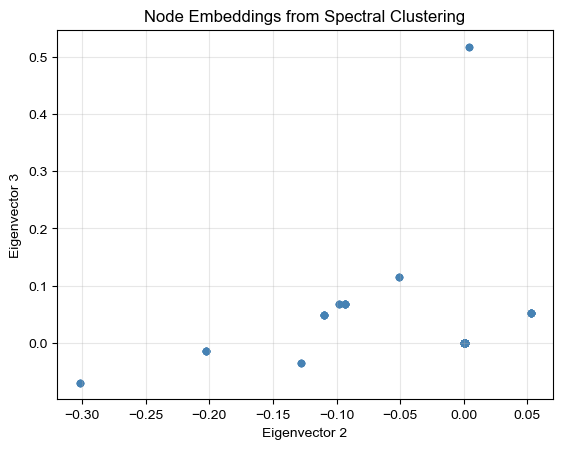

In [ ]:
plt.figure()
plt.scatter(M[:, 0], M[:, 1], s=20, color="steelblue")
plt.title("Node Embeddings from Spectral Clustering")
plt.xlabel("Eigenvector 2")
plt.ylabel("Eigenvector 3")
plt.grid(True, alpha=0.3)
plt.show()

# Method 3: Graph Neural Network (embedding-based)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
generator = torch.Generator(device=device).manual_seed(42)

HID_SIZE = 64
EMB_SIZE = 8

class GCN(nn.Module):
    def __init__(self, graph, hidden_dim, out_dim):
        super().__init__()
        nodes = sorted(graph.nodes())  # ensure consistent node ordering
        self.node_to_row = {node: i for i, node in enumerate(nodes)}

        A = torch.tensor(nx.to_numpy_array(graph, nodelist=nodes), dtype=torch.float32)
        I = torch.eye(A.shape[0], dtype=A.dtype)    # self-loops & node features

        # adjacency matrix with self-loops
        A_hat = A + I

        # inverse degree matrix
        D_hat_inv = torch.diag(1.0 / A_hat.sum(dim=1))  # cheaper than inverse

        self.A_hat = A_hat
        self.D_hat_inv = D_hat_inv
        self.X = I   # one-hot node features

        self.W1 = nn.Parameter(torch.randn(len(nodes), hidden_dim) * 0.01)
        self.W2 = nn.Parameter(torch.randn(hidden_dim, out_dim) * 0.01)

    def forward(self, candidates):
        # layer 1 (input to hidden-dimensional)
        x = self.D_hat_inv @ (self.A_hat @ (self.X @ self.W1))
        x = F.relu(x)

        # layer 2 (hidden-dimensional to embedding-dimensional)
        emb = self.D_hat_inv @ (self.A_hat @ (x @ self.W2))

        u = torch.tensor([self.node_to_row[int(c[0])] for c in candidates], dtype=torch.long)
        v = torch.tensor([self.node_to_row[int(c[1])] for c in candidates], dtype=torch.long)

        # dot product of embeddings
        return (emb[u] * emb[v]).sum(dim=1)  # dot product for each candidate edge

In [13]:
EPOCHS = 100
BATCH_SIZE = 64

model = GCN(g_baseline, hidden_dim=HID_SIZE, out_dim=EMB_SIZE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

batches = DataLoader(TensorDataset(
    torch.tensor(X_train),                       # [8950, 2]
    torch.tensor(Y_train, dtype=torch.float32),  # [8950]
), batch_size=BATCH_SIZE, shuffle=True, generator=generator)

train_loss = []
for epoch in tqdm(range(EPOCHS)):
    model.train()

    batch_loss = []
    for candidates, labels in batches:
        optimizer.zero_grad()

        logits = model(candidates)
        loss = criterion(logits, labels)
        batch_loss.append(loss.item())

        loss.backward()
        optimizer.step()

    train_loss.append(np.average(batch_loss))

    if epoch % 20 == 0:
        print(f"Epoch {epoch} Loss: {train_loss[-1]:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0 Loss: 0.6936
Epoch 20 Loss: 0.1065
Epoch 40 Loss: 0.0419
Epoch 60 Loss: 0.0246
Epoch 80 Loss: 0.0229


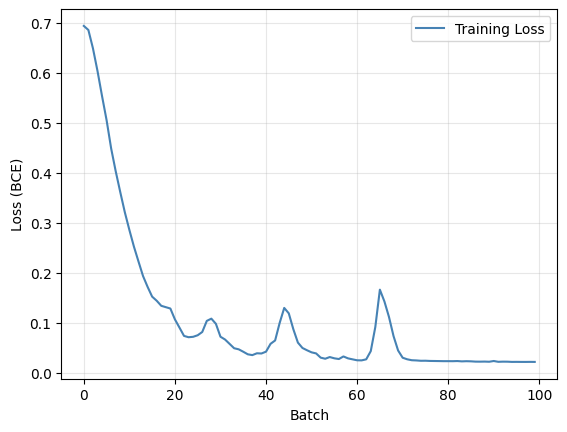

In [ ]:
plt.figure()
plt.plot(train_loss, color="steelblue", label="Training loss")
plt.legend()
plt.xlabel("Batch")
plt.ylabel("Loss (BCE)")
plt.grid(True, alpha=0.3)
plt.show()

# Evaluation

| | Predicted Positive | Predicted Negative |
|---|:-:|:-:|
| **Actual Positive** | TP | FN |
| **Actual Negative** | FP | TN |

* **TP**: edge exists and is predicted
* **FP**: edge *does not* exist but is predicted
* **FN**: edge exists but is *not* predicted
* **TN**: edge *does not* exist and is *not* predicted


$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} \quad\quad
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} \quad\quad
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

> The three metrics will match if the number of predicted positive edges matches the number of true positive edges in the validation set.

In [9]:
def binarize_scores(scores: np.ndarray, top_k=Y_train.count(1)) -> list[int]:
    """Map the scores to 1 if they belong to the top-k."""
    top_k_idx = np.argsort(scores)[-top_k:]
    pred = np.zeros(len(scores))
    pred[top_k_idx] = 1
    return pred.tolist()

NameError: name 'Y_train' is not defined

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

Y_val_pred = binarize_scores(scores)
assert Y_val_pred.count(1) == Y_train.count(1), "The number of predicted positives must match the number of actual positives for a fair evaluation."

precision = precision_score(Y_train, Y_val_pred)
recall = recall_score(Y_train, Y_val_pred)
f1 = f1_score(Y_train, Y_val_pred)

print(f"PR: {precision:.4f}")
print(f"RE: {recall:.4f}")
print(f"F1: {f1:.4f}")

PR: 0.3821
RE: 0.3821
F1: 0.3821
